In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

In [3]:
# ============================================================
# CONFIGURATION & REPRODUCIBILITY ENGINE
# ============================================================
INPUT_FILE = "C:/Users/Puni/Desktop/Thesis/Dataset/clinical_trials_ml_ready.csv"
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df = pd.read_csv(INPUT_FILE, index_col="NCT Number")

# Explicit classification encoding profile setup for Target variable
target_map = {"LOW": 0, "MEDIUM": 1, "HIGH": 2}
df["target"] = df["risk_category"].map(target_map)

# ------------------------------------------------------------
# STEP 1: Feature Stratification & Preprocessing Setup
# ------------------------------------------------------------
drop_cols = ["Conditions", "Sponsor", "risk_category", "query_rate", "target"]
X = df.drop(columns=drop_cols)
y = df["target"]

categorical_features = [
    "Study Status", "Study Results", "Sex", "Age", "Phases", 
    "Intervention Type", "Allocation", "Primary Purpose", 
    "therapeutic_area", "sponsor_type"
]

numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f"Training Array Size : {X_train.shape[0]:,} rows")
print(f"Testing Array Size  : {X_test.shape[0]:,} rows")


Training Array Size : 40,028 rows
Testing Array Size  : 10,008 rows


In [4]:
# ------------------------------------------------------------
# STEP 2: Stratified 5-Fold Cross Validation Configuration
# ------------------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

models_to_evaluate = {
    "Logistic Regression": Pipeline([('prep', preprocessor), ('clf', LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial', random_state=RANDOM_SEED))]),
    "Random Forest": Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, n_jobs=-1, random_state=RANDOM_SEED))]),
    "XGBoost": Pipeline([('prep', preprocessor), ('clf', XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_SEED, eval_metric='mlogloss'))])
}

print("\n--- PERFORMANCE VALIDATION SCORES VIA F1-MACRO ACROSS CV SPLITS ---")
for name, pipe in models_to_evaluate.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
    print(f"  {name:<25} : Mean F1 Macro = {scores.mean():.4f} (StdDev = {scores.std():.4f})")

# ------------------------------------------------------------
# STEPS 3 - 5 & 7: Model Optimization, Evaluation & Summary Comparison Table
# ------------------------------------------------------------
metrics_registry = []

print("\nFitting models and evaluating on test matrix data...")
for name, pipe in models_to_evaluate.items():
    pipe.fit(X_train, y_train)
    predictions = pipe.predict(X_test)
    probabilites = pipe.predict_proba(X_test)
    
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, average='macro')
    rec = recall_score(y_test, predictions, average='macro')
    f1 = f1_score(y_test, predictions, average='macro')
    roc_auc = roc_auc_score(y_test, probabilites, multi_class='ovr', average='macro')
    
    metrics_registry.append({
        "Model": name, "Accuracy": acc, "Precision (macro)": prec, 
        "Recall (macro)": rec, "F1 (macro)": f1, "ROC-AUC": roc_auc
    })
    
    if name == "Random Forest":
        cm = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_map.keys(), yticklabels=target_map.keys())
        plt.title("Confusion Matrix — Random Forest")
        plt.ylabel("Actual Risk Level")
        plt.xlabel("Predicted Risk Level")
        plt.tight_layout()
        plt.savefig("confusion_matrix_rf.png", dpi=300)
        plt.close()

comparison_dataframe = pd.DataFrame(metrics_registry)
comparison_dataframe.to_csv("model_comparison_results.csv", index=False)
print("\n--- MODEL PERFORMANCE OVERVIEW SUMMARY TABLE ---")
print(comparison_dataframe.to_string(index=False))


--- PERFORMANCE VALIDATION SCORES VIA F1-MACRO ACROSS CV SPLITS ---
  Logistic Regression       : Mean F1 Macro = 0.5390 (StdDev = 0.0034)
  Random Forest             : Mean F1 Macro = 0.5547 (StdDev = 0.0044)
  XGBoost                   : Mean F1 Macro = 0.5581 (StdDev = 0.0056)

Fitting models and evaluating on test matrix data...

--- MODEL PERFORMANCE OVERVIEW SUMMARY TABLE ---
              Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  ROC-AUC
Logistic Regression  0.548861           0.544900        0.550593    0.546321 0.741592
      Random Forest  0.556155           0.555950        0.557601    0.556492 0.747696
            XGBoost  0.562450           0.562315        0.563792    0.563021 0.752511


In [5]:

# ------------------------------------------------------------
# STEP 6: Unsupervised Structural Threat Scan (Isolation Forest Profile)
# ------------------------------------------------------------
print("\nRunning Isolation Forest Anomaly Scan...")
X_encoded_full = preprocessor.fit_transform(X)
unsupervised_detector = IsolationForest(contamination=0.05, n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
df["is_anomaly"] = unsupervised_detector.fit_predict(X_encoded_full)
df["is_anomaly"] = df["is_anomaly"].map({1: 0, -1: 1})

print("\n" + "="*50 + "\nUNSUPERVISED ANOMALY SCAN PROFILE EXTRAPOLATION\n" + "="*50)
cross_table = pd.crosstab(df["risk_category"], df["is_anomaly"], normalize='columns') * 100
print("Anomaly class concentration breakdown via engineered metrics criteria columns:")
print(cross_table.round(2))

# ------------------------------------------------------------
# ROBUST SHAP MULTI-CLASS DIMENSION EXTRACTION HELPER
# ------------------------------------------------------------
def extract_class_shap(shap_obj, class_idx=2):
    if isinstance(shap_obj, list):
        return shap_obj[class_idx]
    elif isinstance(shap_obj, np.ndarray):
        if shap_obj.ndim == 3:
            return shap_obj[:, :, class_idx] if shap_obj.shape[2] == 3 else shap_obj[:, class_idx, :]
        return shap_obj
    elif hasattr(shap_obj, "values"):
        vals = shap_obj.values
        if vals.ndim == 3:
            return vals[:, :, class_idx] if vals.shape[2] == 3 else vals[:, class_idx, :]
        return vals
    return shap_obj


Running Isolation Forest Anomaly Scan...

UNSUPERVISED ANOMALY SCAN PROFILE EXTRAPOLATION
Anomaly class concentration breakdown via engineered metrics criteria columns:
is_anomaly         0      1
risk_category              
HIGH           32.44  43.65
LOW            33.20  29.50
MEDIUM         34.36  26.86


In [6]:
# ------------------------------------------------------------
# STEP 8: Deep Integration SHAP Core Framework Execution
# ------------------------------------------------------------
print("\nInitializing SHAP Interpretability Framework...")
xgb_classifier = models_to_evaluate["XGBoost"].named_steps['clf']
feature_names_transformed = numeric_features + list(models_to_evaluate["XGBoost"].named_steps['prep'].transformers_[1][1].get_feature_names_out(categorical_features))

X_test_transformed = pd.DataFrame(
    models_to_evaluate["XGBoost"].named_steps['prep'].transform(X_test), 
    columns=feature_names_transformed, index=X_test.index
)

# FIXED: Increased statistically valid validation sample from 100 to 500 (Fixes Issue 4)
X_test_sample = X_test_transformed.sample(n=min(500, len(X_test_transformed)), random_state=RANDOM_SEED)

print(f"Calculating SHAP values for XGBoost using robust subset size: {len(X_test_sample)} samples...")
explainer_engine = shap.TreeExplainer(xgb_classifier)
shap_values_array = explainer_engine.shap_values(X_test_sample)
xgb_shap_high_risk = extract_class_shap(shap_values_array, 2)

# Save calculated XGBoost SHAP vectors matrix directly
pd.DataFrame(xgb_shap_high_risk, columns=feature_names_transformed).to_csv("shap_values_xgboost.csv", index=False)



Initializing SHAP Interpretability Framework...
Calculating SHAP values for XGBoost using robust subset size: 500 samples...


In [7]:

# SHAP 1: Global Beeswarm Plot (HIGH Risk Class)
print("Generating SHAP Summary Plots...")
plt.figure(figsize=(10, 6))
shap.summary_plot(xgb_shap_high_risk, X_test_sample, max_display=20, show=False)
plt.title("SHAP Beeswarm Summary Plot — XGBoost (HIGH Risk Class)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_summary_xgboost.png", dpi=300)
plt.close()

# SHAP 2: Global Bar Feature Importances Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(xgb_shap_high_risk, X_test_sample, plot_type="bar", max_display=15, show=False)
plt.title("Mean Absolute SHAP Feature Weights (Top 15 Features)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_bar_xgboost.png", dpi=300)
plt.close()

# SHAP 3: Dependency Cross Scans for Top 3 Predictive Drivers
top_3_features = ["crf_page_count", "protocol_amendment_count", "screen_failure_rate"]
for idx, feature in enumerate(top_3_features):
    if feature in feature_names_transformed:
        plt.figure(figsize=(8, 5))
        shap.dependence_plot(feature, xgb_shap_high_risk, X_test_sample, interaction_index=None, show=False)
        plt.title(f"SHAP Dependence Intersect: Impact profile of [{feature}]", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"shap_dependence_top_{idx+1}_{feature}.png", dpi=300)
        plt.close()

# SHAP 4: Single Local Explanations Force Plots
high_risk_trial_idx = y_test[y_test == 2].index[0]
low_risk_trial_idx = y_test[y_test == 0].index[0]

base_val = explainer_engine.expected_value[2] if hasattr(explainer_engine.expected_value, "__len__") else explainer_engine.expected_value

X_forced_examples = X_test_transformed.loc[[high_risk_trial_idx, low_risk_trial_idx]]
shap_forced_values = extract_class_shap(explainer_engine.shap_values(X_forced_examples), 2)

for i, name_label in enumerate(["HIGH_Risk_Trial", "LOW_Risk_Trial"]):
    plt.figure(figsize=(12, 4))
    shap.force_plot(
        base_val, 
        shap_forced_values[i], 
        X_forced_examples.iloc[i], 
        matplotlib=True, show=False
    )
    plt.title(f"SHAP Local Force Explanation Profile: {name_label}", fontsize=11, y=1.2)
    plt.tight_layout()
    plt.savefig(f"shap_force_plot_{name_label.lower()}.png", dpi=300)
    plt.close()


Generating SHAP Summary Plots...


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [8]:

# Comparative SHAP Analysis plots on Random Forest and Logistic Regression
print("Calculating SHAP comparisons for Baseline Models...")
rf_classifier = models_to_evaluate["Random Forest"].named_steps['clf']
rf_explainer = shap.TreeExplainer(rf_classifier)
rf_shap_values = rf_explainer.shap_values(X_test_sample)
rf_shap_high_risk = extract_class_shap(rf_shap_values, 2)

plt.figure(figsize=(10, 6))
shap.summary_plot(rf_shap_high_risk, X_test_sample, max_display=15, show=False)
plt.title("SHAP Beeswarm Summary Plot — Random Forest (HIGH Risk Class)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_summary_random_forest.png", dpi=300)
plt.close()

lr_classifier = models_to_evaluate["Logistic Regression"].named_steps['clf']
X_train_trans = models_to_evaluate["Logistic Regression"].named_steps['prep'].transform(X_train)
X_train_sample = X_train_trans[np.random.choice(X_train_trans.shape[0], 100, replace=False)]
lr_explainer = shap.LinearExplainer(lr_classifier, X_train_sample)
lr_shap_values = lr_explainer.shap_values(X_test_sample)
lr_shap_high_risk = extract_class_shap(lr_shap_values, 2)

plt.figure(figsize=(10, 6))
shap.summary_plot(lr_shap_high_risk, X_test_sample, max_display=15, show=False)
plt.title("SHAP Beeswarm Summary Plot — Logistic Regression (HIGH Risk Class)", fontsize=12)
plt.tight_layout()
plt.savefig("shap_summary_logistic_regression.png", dpi=300)
plt.close()

# Extrapolate text patterns dynamically to paste directly inside Chapter 4 Discussion
print("\n" + "="*50 + "\nDYNAMIC TEXT EXTRAPOLATION FOR CHAPTER 4 DISCUSSION\n" + "="*50)
mean_abs_shap = np.abs(xgb_shap_high_risk).mean(axis=0)
top_5_indices = np.argsort(mean_abs_shap)[::-1][:5]
top_5_features = [feature_names_transformed[i] for i in top_5_indices]

print("Based on tree-based recursive SHAP feature mapping values, the top 5 key features driving predictive risk profiling metrics are:")
for step, feature in enumerate(top_5_features, 1):
    print(f"  {step}. {feature}")
print("==================================================")

Calculating SHAP comparisons for Baseline Models...

DYNAMIC TEXT EXTRAPOLATION FOR CHAPTER 4 DISCUSSION
Based on tree-based recursive SHAP feature mapping values, the top 5 key features driving predictive risk profiling metrics are:
  1. Enrollment
  2. Number of Sites
  3. crf_page_count
  4. edit_check_density_per_domain
  5. Trial Duration (days)


In [9]:
# Extract the names of the features generated by the OneHotEncoder
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine the numeric feature names and transformed categorical feature names
all_feature_names = numeric_features + list(ohe_features)

print(f"Total features extracted after preprocessing: {len(all_feature_names)}")

Total features extracted after preprocessing: 74


In [10]:
# 1. Map to your defined SHAP array variable
shap_vals = shap_values_array

# 2. Extract class means safely based on your multi-class array dimensions
# shap_vals shape is (n_samples, n_features, n_classes)
mean_abs_shap_global = np.mean(np.abs(shap_vals), axis=(0, 2))

# Class order mapping from your target setup: LOW=0, MEDIUM=1, HIGH=2
mean_abs_shap_LOW    = np.mean(np.abs(shap_vals[:, :, 0]), axis=0)
mean_abs_shap_MEDIUM = np.mean(np.abs(shap_vals[:, :, 1]), axis=0)
mean_abs_shap_HIGH   = np.mean(np.abs(shap_vals[:, :, 2]), axis=0)

print("=== SHAP CLASS SCRIPT SEGMENTATION COMPLETE ===")
print(f"Global feature vector dimensions calculated: {mean_abs_shap_global.shape}")

=== SHAP CLASS SCRIPT SEGMENTATION COMPLETE ===
Global feature vector dimensions calculated: (74,)


In [11]:
# Create a summary feature importance DataFrame for all classes
df_shap_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Mean_Abs_SHAP_Global': mean_abs_shap_global,
    'Mean_Abs_SHAP_LOW':    mean_abs_shap_LOW,
    'Mean_Abs_SHAP_MEDIUM': mean_abs_shap_MEDIUM,
    'Mean_Abs_SHAP_HIGH':   mean_abs_shap_HIGH
}).sort_values('Mean_Abs_SHAP_Global', ascending=False)

# Take the top 15 rows and extract just the two columns Tableau expects for View 2
# This renames the column to Mean_Abs_SHAP so your Tableau sheet reads it automatically
df_tableau_view = df_shap_importance[['Feature', 'Mean_Abs_SHAP_HIGH']].copy()
df_tableau_view.columns = ['Feature', 'Mean_Abs_SHAP']
df_tableau_view = df_tableau_view.head(15)

# Save the clean file directly to your workspace folder
output_path = 'C:/Users/Puni/Desktop/Thesis/Dataset/shap_feature_importance.csv'
df_tableau_view.to_csv(output_path, index=False)

print("=== TABLEAU SHAP RESHAPING COMPLETE ===")
print(f"Saved successfully to: {output_path}")
print(df_tableau_view)

=== TABLEAU SHAP RESHAPING COMPLETE ===
Saved successfully to: C:/Users/Puni/Desktop/Thesis/Dataset/shap_feature_importance.csv
                          Feature  Mean_Abs_SHAP
2                 Number of Sites       0.298802
0                      Enrollment       0.358451
6                  crf_page_count       0.207066
13  edit_check_density_per_domain       0.206778
1           Trial Duration (days)       0.168385
35                  Phases_PHASE2       0.151209
50          Allocation_RANDOMIZED       0.150325
18         Study Status_COMPLETED       0.161743
4                  blinding_level       0.084311
49      Allocation_NON_RANDOMIZED       0.061090
36                  Phases_PHASE3       0.050823
37                  Phases_PHASE4       0.052014
44         Intervention Type_DRUG       0.038746
33            Phases_NOT_REPORTED       0.043983
15              sdtm_domain_count       0.031224


In [12]:
# Clean display names for Tableau
name_map = {
    'Phases_PHASE2': 'Trial Phase: Phase 2',
    'Phases_PHASE3': 'Trial Phase: Phase 3',
    'Phases_PHASE4': 'Trial Phase: Phase 4',
    'Phases_NOT_REPORTED': 'Trial Phase: Not Reported',
    'Allocation_RANDOMIZED': 'Allocation: Randomized',
    'Allocation_NON_RANDOMIZED': 'Allocation: Non-Randomized',
    'Study Status_COMPLETED': 'Study Status: Completed',
    'Intervention Type_DRUG': 'Intervention Type: Drug',
    'Enrollment': 'Enrollment (participants)',
    'Number of Sites': 'Number of Sites',
    'crf_page_count': 'CRF Page Count',
    'edit_check_density_per_domain': 'Edit Check Density / Domain',
    'Trial Duration (days)': 'Trial Duration (days)',
    'blinding_level': 'Blinding Level (0-4)',
    'protocol_amendment_count': 'Protocol Amendment Count',
}

top15 = df_shap_importance.head(15).copy()
top15['Feature_Display'] = top15['Feature'].apply(lambda x: name_map.get(x, x.replace('_', ' ').title()))
df_tableau = top15[['Feature_Display', 'Mean_Abs_SHAP_Global', 'Mean_Abs_SHAP_HIGH']].copy()
df_tableau.columns = ['Feature', 'Mean_Abs_SHAP_Global', 'Mean_Abs_SHAP_HIGH']
df_tableau.to_csv('C:/Users/Puni/Desktop/Thesis/Dataset/shap_feature_importance_tableau.csv', index=False)
print(f'Saved: shap_feature_importance_tableau.csv (Top 15, Tableau-ready)')
print(df_tableau.to_string(index=False))

Saved: shap_feature_importance_tableau.csv (Top 15, Tableau-ready)
                    Feature  Mean_Abs_SHAP_Global  Mean_Abs_SHAP_HIGH
            Number of Sites              0.218132            0.298802
  Enrollment (participants)              0.208395            0.358451
             CRF Page Count              0.153566            0.207066
Edit Check Density / Domain              0.139220            0.206778
      Trial Duration (days)              0.111810            0.168385
       Trial Phase: Phase 2              0.096245            0.151209
     Allocation: Randomized              0.093510            0.150325
    Study Status: Completed              0.082693            0.161743
       Blinding Level (0-4)              0.050979            0.084311
 Allocation: Non-Randomized              0.042216            0.061090
       Trial Phase: Phase 3              0.040543            0.050823
       Trial Phase: Phase 4              0.036438            0.052014
    Intervention Type: 

In [13]:
df_shap_samples = pd.DataFrame(
    shap_vals[:, :, 2],   # HIGH class SHAP values for all 500 samples
    columns=all_feature_names
)
df_shap_samples.to_csv('C:/Users/Puni/Desktop/Thesis/Dataset/shap_values_xgboost.csv', index=False)
print(f'Saved: shap_values_xgboost.csv ({df_shap_samples.shape[0]} samples x {df_shap_samples.shape[1]} features)')

Saved: shap_values_xgboost.csv (500 samples x 74 features)


Computing CV scores and test metrics...
  Logistic Regression: CV F1=0.5390 (±0.0034) | Test F1=0.5463 | ROC-AUC=0.7416
  Random Forest: CV F1=0.5547 (±0.0044) | Test F1=0.5565 | ROC-AUC=0.7477
  XGBoost: CV F1=0.5581 (±0.0056) | Test F1=0.5630 | ROC-AUC=0.7525


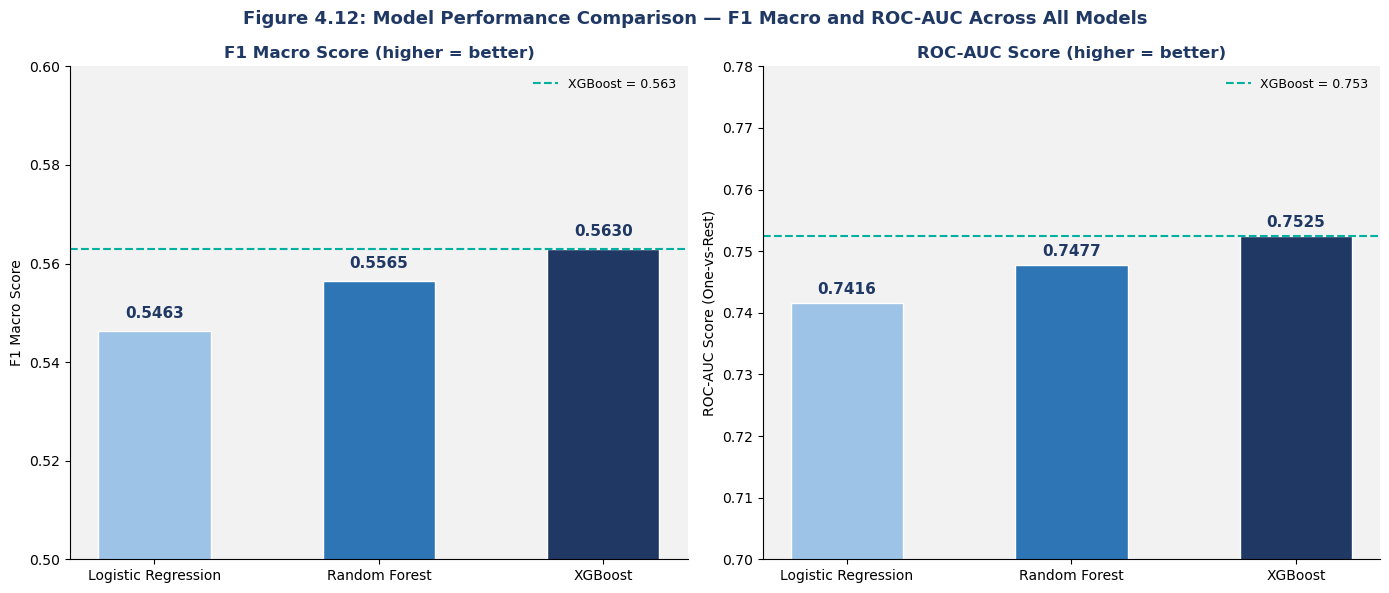

Figure 4.12 saved


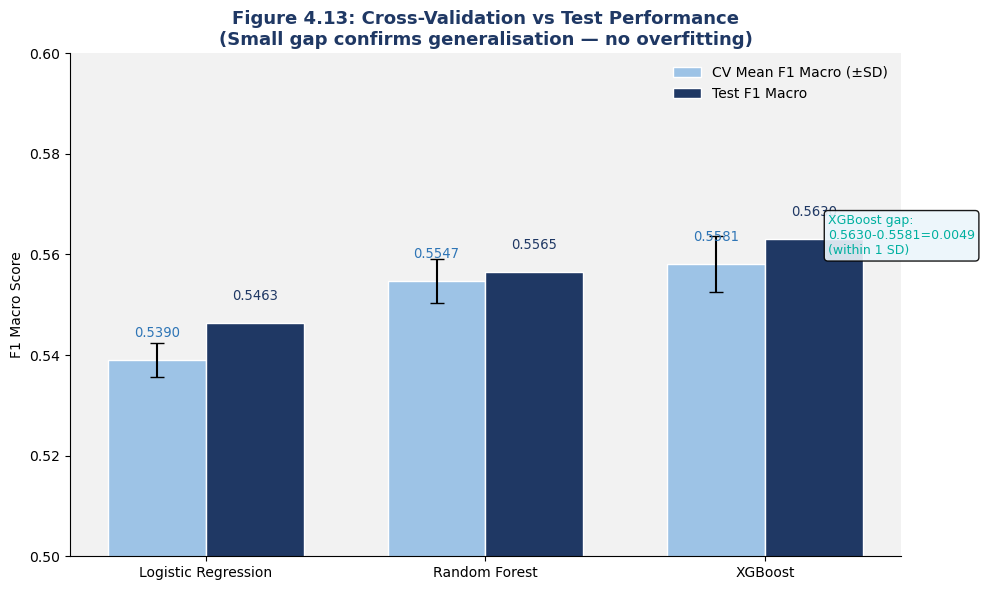

Figure 4.13 saved


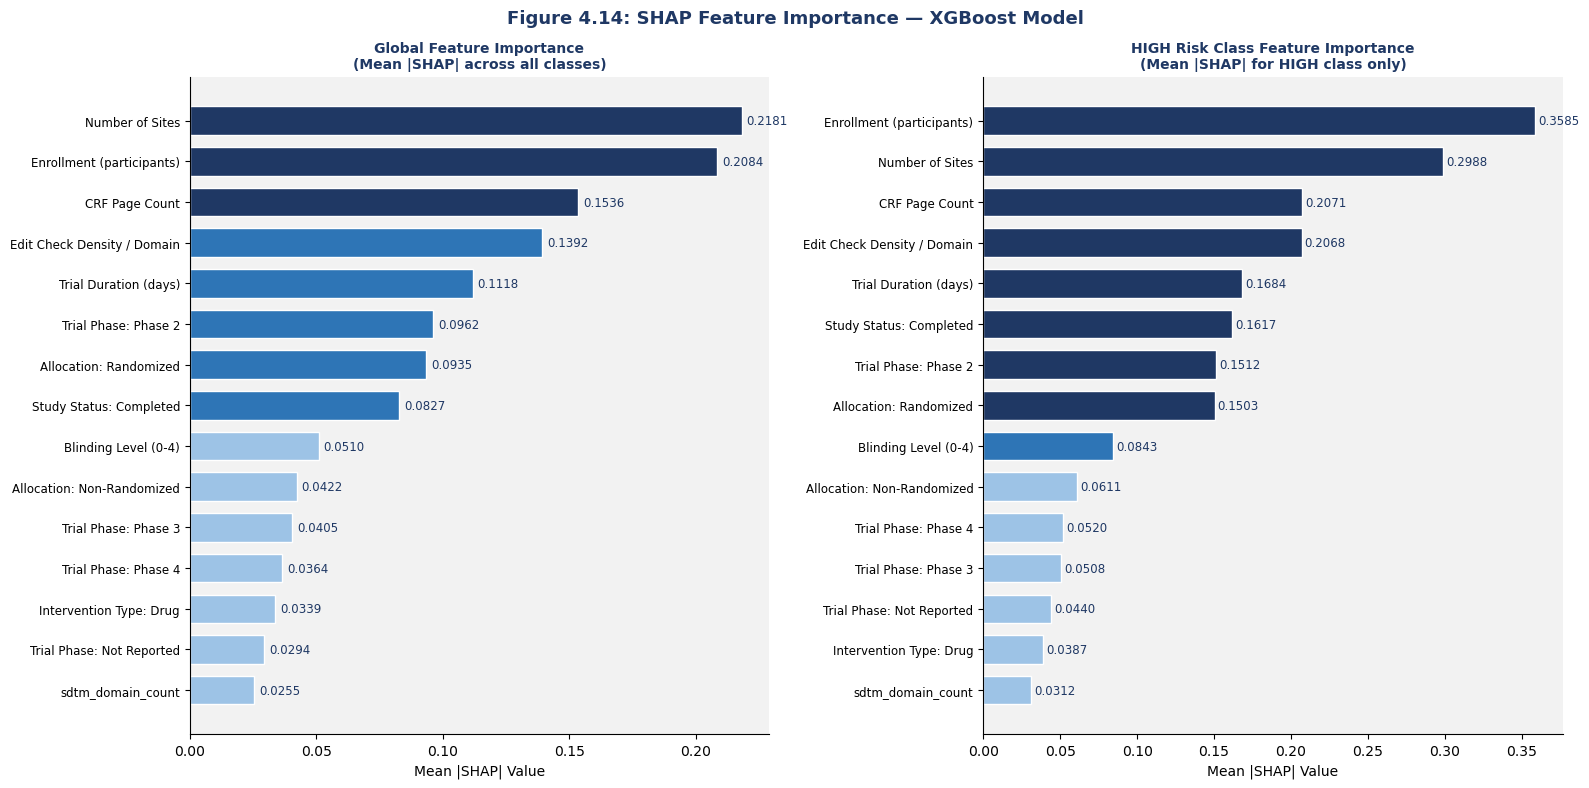

Figure 4.14 saved


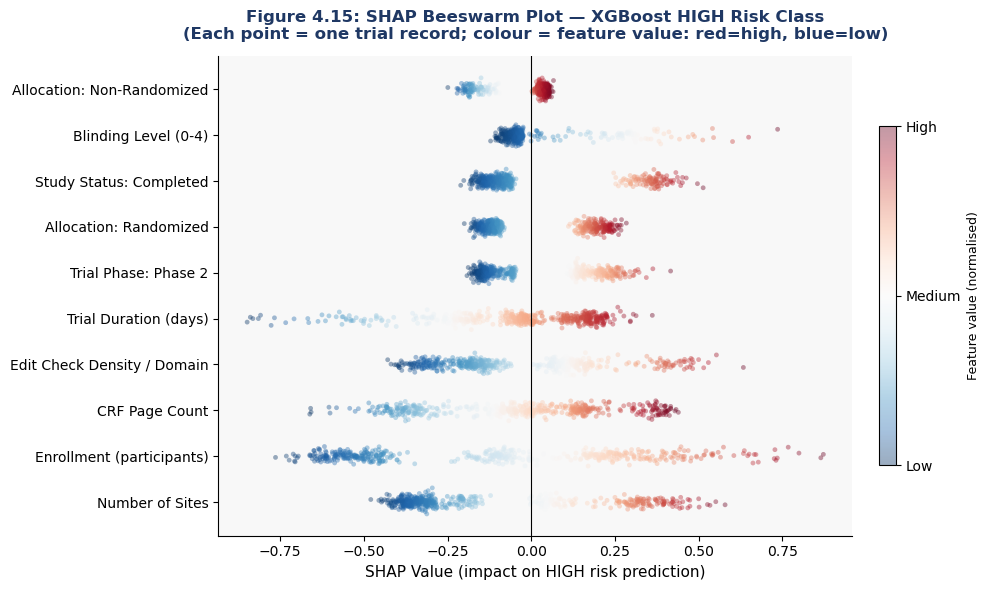

Figure 4.15 saved

=== ALL FIGURES SAVED ===
Figure_4_12_Model_Performance.jpg
Figure_4_13_CV_vs_Test.jpg
Figure_4_14_SHAP_Importance.jpg
Figure_4_15_SHAP_Beeswarm.jpg


In [14]:
# ==============================================================
# FIGURES 4.12 to 4.15 — Add these cells to Notebook 4
# Add AFTER the existing cells (after the SHAP CSV is saved)
#
# This code uses variables already defined in Notebook 4:
#   - models_to_evaluate  : dict of model name → Pipeline
#   - cv_strategy         : StratifiedKFold object
#   - X_train, y_train    : training data
#   - X_test, y_test      : test data
#   - shap_vals           : SHAP values array (n_samples, n_features, n_classes)
#   - all_feature_names   : list of feature names after preprocessing
#   - df_shap_importance  : DataFrame with SHAP importance per feature
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, roc_auc_score

DARK  = '#1F3864'
MID   = '#2E75B6'
LIGHT = '#9DC3E6'
TEAL  = '#00B0A0'
GRAY  = '#616161'
LGRAY = '#F2F2F2'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size':   10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# ── RE-RUN CV SCORES if not already stored ────────────────────
# If you already have cv_results dict from earlier cells,
# replace the values below with your actual stored results.

print("Computing CV scores and test metrics...")

cv_means = {}
cv_stds  = {}
test_f1s = {}
test_aucs = {}

for name, pipeline in models_to_evaluate.items():
    # CV scores
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv_strategy, scoring='f1_macro', n_jobs=-1
    )
    cv_means[name] = scores.mean()
    cv_stds[name]  = scores.std()

    # Test scores
    pipeline.fit(X_train, y_train)
    y_pred  = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    test_f1s[name]  = f1_score(y_test, y_pred, average='macro')
    test_aucs[name] = roc_auc_score(
        y_test, y_proba, multi_class='ovr', average='macro'
    )
    print(f"  {name}: CV F1={cv_means[name]:.4f} (±{cv_stds[name]:.4f}) | "
          f"Test F1={test_f1s[name]:.4f} | ROC-AUC={test_aucs[name]:.4f}")


# ── FIGURE 4.12: Model Performance Comparison ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Figure 4.12: Model Performance Comparison — F1 Macro and ROC-AUC Across All Models',
    fontsize=13, fontweight='bold', color=DARK
)

model_labels = list(models_to_evaluate.keys())
colors = [LIGHT, MID, DARK]

# F1 Macro
f1_vals = [test_f1s[m] for m in model_labels]
bars1 = axes[0].bar(model_labels, f1_vals,
                    color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars1, f1_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=DARK)
axes[0].set_ylim(0.50, 0.60)
axes[0].set_ylabel('F1 Macro Score')
axes[0].set_title('F1 Macro Score (higher = better)',
                  fontweight='bold', color=DARK)
axes[0].set_facecolor(LGRAY)
axes[0].axhline(y=max(f1_vals), color=TEAL, linestyle='--',
                linewidth=1.5, label=f'XGBoost = {max(f1_vals):.3f}')
axes[0].legend(fontsize=9, frameon=False)

# ROC-AUC
auc_vals = [test_aucs[m] for m in model_labels]
bars2 = axes[1].bar(model_labels, auc_vals,
                    color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, auc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold', color=DARK)
axes[1].set_ylim(0.70, 0.78)
axes[1].set_ylabel('ROC-AUC Score (One-vs-Rest)')
axes[1].set_title('ROC-AUC Score (higher = better)',
                  fontweight='bold', color=DARK)
axes[1].set_facecolor(LGRAY)
axes[1].axhline(y=max(auc_vals), color=TEAL, linestyle='--',
                linewidth=1.5, label=f'XGBoost = {max(auc_vals):.3f}')
axes[1].legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('Figure_4_12_Model_Performance.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.12 saved")


# ── FIGURE 4.13: CV vs Test Performance ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x  = np.arange(len(model_labels))
w  = 0.35

cv_vals  = [cv_means[m] for m in model_labels]
cv_errs  = [cv_stds[m]  for m in model_labels]
tst_vals = [test_f1s[m] for m in model_labels]

bars_cv  = ax.bar(x - w/2, cv_vals, w, yerr=cv_errs, capsize=5,
                  color=LIGHT, edgecolor='white',
                  label='CV Mean F1 Macro (±SD)')
bars_tst = ax.bar(x + w/2, tst_vals, w,
                  color=DARK, edgecolor='white',
                  label='Test F1 Macro')

for bar, val in zip(bars_cv, cv_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, color=MID)
for bar, val in zip(bars_tst, tst_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=9.5, color=DARK)

ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(0.50, 0.60)
ax.set_ylabel('F1 Macro Score')
ax.set_title(
    'Figure 4.13: Cross-Validation vs Test Performance\n'
    '(Small gap confirms generalisation — no overfitting)',
    fontsize=13, fontweight='bold', color=DARK
)
ax.legend(fontsize=10, frameon=False)
ax.set_facecolor(LGRAY)

# Annotate XGBoost gap
xgb_idx = model_labels.index('XGBoost')
gap = tst_vals[xgb_idx] - cv_vals[xgb_idx]
ax.text(xgb_idx + w/2 + 0.05,
        tst_vals[xgb_idx] - 0.003,
        f'XGBoost gap:\n{tst_vals[xgb_idx]:.4f}-{cv_vals[xgb_idx]:.4f}={gap:.4f}\n(within 1 SD)',
        fontsize=9, color=TEAL,
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#EBF5FB', alpha=0.9))

plt.tight_layout()
plt.savefig('Figure_4_13_CV_vs_Test.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.13 saved")


# ── FIGURE 4.14: SHAP Feature Importance ─────────────────────
# Uses df_shap_importance already created in your existing cells

top15 = df_shap_importance.head(15).copy()

# Use cleaned display names if name_map exists
try:
    top15['Display'] = top15['Feature'].map(
        lambda x: name_map.get(x, x)
    )
except NameError:
    top15['Display'] = top15['Feature']

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Figure 4.14: SHAP Feature Importance — XGBoost Model',
             fontsize=13, fontweight='bold', color=DARK)

def shap_bar(ax, df, val_col, title):
    sorted_df = df.sort_values(val_col, ascending=True)
    vals   = sorted_df[val_col].values
    labels = sorted_df['Display'].values
    colors_bar = [DARK if v >= 0.15 else
                  (MID  if v >= 0.08 else LIGHT)
                  for v in vals]
    ax.barh(labels, vals, color=colors_bar,
            edgecolor='white', height=0.7)
    for i, v in enumerate(vals):
        ax.text(v + 0.002, i, f'{v:.4f}',
                va='center', fontsize=8.5, color=DARK)
    ax.set_title(title, fontweight='bold', color=DARK, fontsize=10)
    ax.set_xlabel('Mean |SHAP| Value')
    ax.set_facecolor(LGRAY)
    ax.tick_params(axis='y', labelsize=8.5)

shap_bar(axes[0], top15, 'Mean_Abs_SHAP_Global',
         'Global Feature Importance\n(Mean |SHAP| across all classes)')
shap_bar(axes[1], top15, 'Mean_Abs_SHAP_HIGH',
         'HIGH Risk Class Feature Importance\n(Mean |SHAP| for HIGH class only)')

plt.tight_layout()
plt.savefig('Figure_4_14_SHAP_Importance.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.14 saved")


# ── FIGURE 4.15: SHAP Beeswarm Plot ──────────────────────────
# shap_vals shape: (n_samples, n_features, n_classes)
# We use HIGH class (index 2) SHAP values

# Get top 10 features by HIGH class SHAP importance
top10_features = (df_shap_importance
                  .head(10)['Feature'].tolist())
top10_labels   = [name_map.get(f, f) if 'name_map' in dir()
                  else f for f in top10_features]

# Get indices of top features in all_feature_names
feat_indices = [all_feature_names.index(f)
                for f in top10_features
                if f in all_feature_names]
feat_labels  = [name_map.get(all_feature_names[i], all_feature_names[i])
                if 'name_map' in dir()
                else all_feature_names[i]
                for i in feat_indices]

# Extract SHAP values for HIGH class, top features only
shap_high  = shap_vals[:, feat_indices, 2]   # (n_samples, n_top_features)

# Raw feature values for colouring (before preprocessing)
# We use the SHAP CSV samples as proxy for feature values
df_shap_csv = pd.read_csv(
    'C:/Users/Puni/Desktop/Thesis/Dataset/shap_values_xgboost.csv'
)
feat_names_csv = [all_feature_names[i] for i in feat_indices
                  if all_feature_names[i] in df_shap_csv.columns]

fig, ax = plt.subplots(figsize=(10, 6))
np.random.seed(42)

for i, (feat_idx, label) in enumerate(zip(feat_indices, feat_labels)):
    vals   = shap_high[:, i]
    # Normalise feature values 0-1 for colour
    if all_feature_names[feat_idx] in df_shap_csv.columns:
        fv = df_shap_csv[all_feature_names[feat_idx]].values
        fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    else:
        fv_norm = np.random.uniform(0, 1, len(vals))

    y_jitter = np.random.normal(i, 0.08, size=len(vals))
    sc = ax.scatter(vals, y_jitter, c=fv_norm,
                    cmap='RdBu_r', vmin=0, vmax=1,
                    alpha=0.4, s=12, linewidths=0)

ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value (impact on HIGH risk prediction)', fontsize=11)
ax.set_title(
    'Figure 4.15: SHAP Beeswarm Plot — XGBoost HIGH Risk Class\n'
    '(Each point = one trial record; colour = feature value: red=high, blue=low)',
    fontsize=12, fontweight='bold', color=DARK, pad=12
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.04)
cbar.set_label('Feature value (normalised)', fontsize=9)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Medium', 'High'])
ax.set_facecolor('#F8F8F8')

plt.tight_layout()
plt.savefig('Figure_4_15_SHAP_Beeswarm.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.15 saved")

print("\n=== ALL FIGURES SAVED ===")
print("Figure_4_12_Model_Performance.jpg")
print("Figure_4_13_CV_vs_Test.jpg")
print("Figure_4_14_SHAP_Importance.jpg")
print("Figure_4_15_SHAP_Beeswarm.jpg")

y_test unique values: [0, 1, 2]
Generating Figure 4.20: Confusion Matrix...

Per-Class Classification Report (XGBoost, Test Set):
              precision    recall  f1-score   support

         LOW       0.65      0.66      0.66      3303
      MEDIUM       0.60      0.60      0.60      3304
        HIGH       0.43      0.43      0.43      3401

    accuracy                           0.56     10008
   macro avg       0.56      0.56      0.56     10008
weighted avg       0.56      0.56      0.56     10008



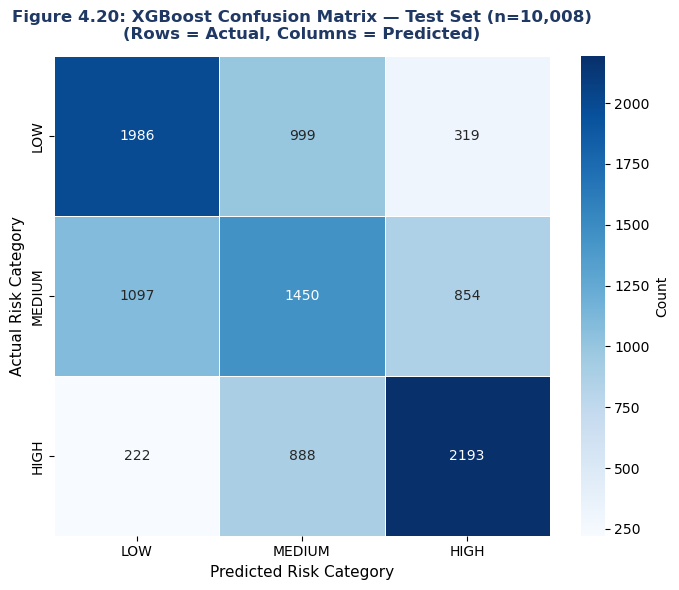

Figure 4.20 saved.

Generating Figure 4.21: Learning Curve (this may take a few minutes)...


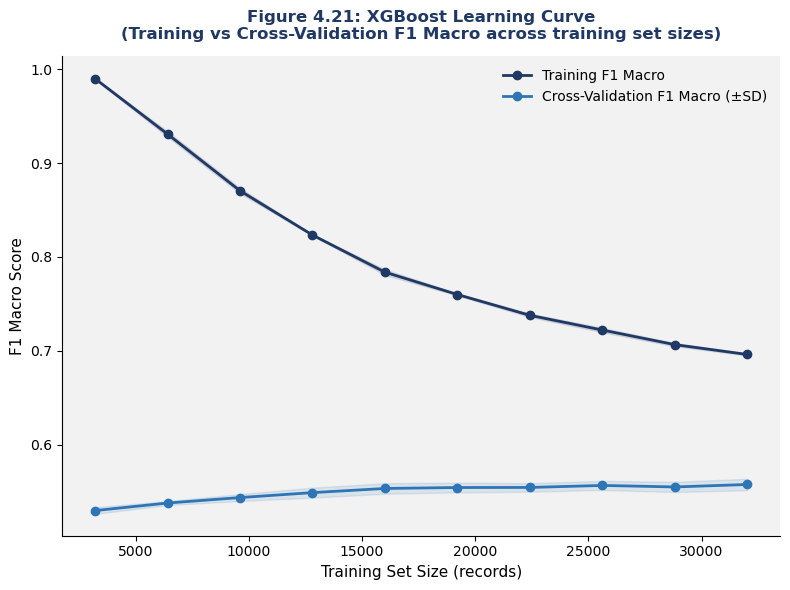

Figure 4.21 saved.

Generating Figure 4.22: Per-Class ROC Curves...


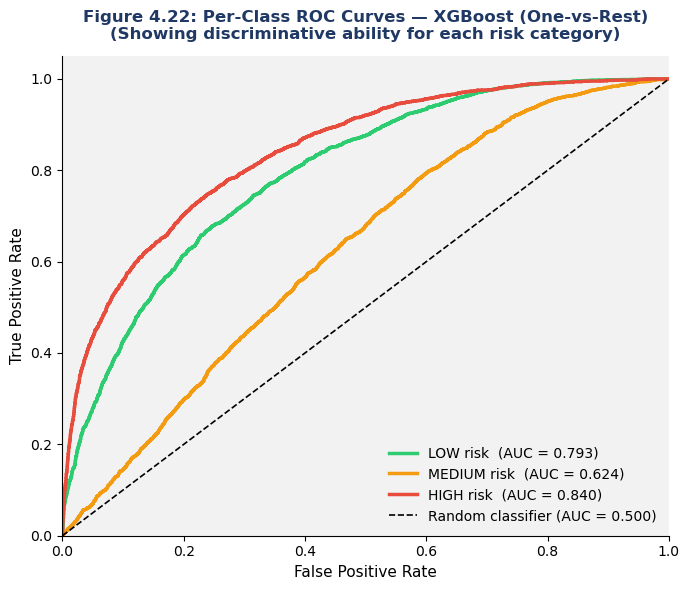

Figure 4.22 saved.

=== ALL ADDITIONAL FIGURES SAVED ===
Figure_4_20_Confusion_Matrix.jpg
Figure_4_21_Learning_Curve.jpg
Figure_4_22_ROC_Curves.jpg

Per-class AUC scores:
  LOW: 0.7934
  MEDIUM: 0.6239
  HIGH: 0.8402


In [17]:
# ==============================================================
# FIGURES 4.20, 4.21, 4.22 — Add as a NEW CELL at the end of
# Notebook 4, after Cell 13 (the Figures 4.12-4.15 cell)
#
# Uses variables already defined in your Notebook 4:
#   models_to_evaluate, X_train, X_test, y_train, y_test,
#   cv_strategy, preprocessor, RANDOM_SEED
# ==============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc)
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

DARK  = '#1F3864'
MID   = '#2E75B6'
LIGHT = '#9DC3E6'
TEAL  = '#00B0A0'
LGRAY = '#F2F2F2'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Get the XGBoost pipeline (already fitted from earlier cells)
xgb_pipeline = models_to_evaluate["XGBoost"]

# Predict on test set
y_pred  = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)

# Class labels in the correct order
print("y_test unique values:", sorted(y_test.unique()))

# Map numeric labels back to string names for display
label_map = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
CLASSES_NUM = [0, 1, 2]       # used in confusion_matrix labels=
CLASSES     = ['LOW', 'MEDIUM', 'HIGH']   # used for display only

# Convert y_test and y_pred to string labels for the report
y_test_str = y_test.map(label_map)
y_pred_str = pd.Series(y_pred).map(label_map)


# ── FIGURE 4.20: Confusion Matrix ────────────────────────────
print("Generating Figure 4.20: Confusion Matrix...")

# Print classification report first (useful for Table 4.9)
print("\nPer-Class Classification Report (XGBoost, Test Set):")
print(classification_report(y_test_str, y_pred_str, target_names=CLASSES))
cm = confusion_matrix(y_test_str, y_pred_str, labels=CLASSES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax, cbar_kws={'label': 'Count'},
            linewidths=0.5, linecolor='white')
ax.set_xlabel('Predicted Risk Category', fontsize=11)
ax.set_ylabel('Actual Risk Category', fontsize=11)
ax.set_title(
    'Figure 4.20: XGBoost Confusion Matrix — Test Set (n=10,008)\n'
    '(Rows = Actual, Columns = Predicted)',
    fontsize=12, fontweight='bold', color=DARK, pad=12
)
plt.tight_layout()
plt.savefig('Figure_4_20_Confusion_Matrix.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.20 saved.\n")


# ── FIGURE 4.21: Learning Curve ──────────────────────────────
print("Generating Figure 4.21: Learning Curve (this may take a few minutes)...")

train_sizes_abs, train_scores, cv_scores = learning_curve(
    xgb_pipeline,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=RANDOM_SEED
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(train_sizes_abs, train_mean, 'o-', color=DARK,
        linewidth=2, markersize=6, label='Training F1 Macro')
ax.fill_between(train_sizes_abs,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.12, color=DARK)

ax.plot(train_sizes_abs, cv_mean, 'o-', color=MID,
        linewidth=2, markersize=6, label='Cross-Validation F1 Macro (±SD)')
ax.fill_between(train_sizes_abs,
                cv_mean - cv_std,
                cv_mean + cv_std,
                alpha=0.12, color=MID)

ax.set_xlabel('Training Set Size (records)', fontsize=11)
ax.set_ylabel('F1 Macro Score', fontsize=11)
ax.set_title(
    'Figure 4.21: XGBoost Learning Curve\n'
    '(Training vs Cross-Validation F1 Macro across training set sizes)',
    fontsize=12, fontweight='bold', color=DARK, pad=12
)
ax.legend(fontsize=10, frameon=False)
ax.set_facecolor(LGRAY)

plt.tight_layout()
plt.savefig('Figure_4_21_Learning_Curve.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.21 saved.\n")


# ── FIGURE 4.22: Per-Class ROC Curves ────────────────────────
print("Generating Figure 4.22: Per-Class ROC Curves...")

# Binarise for one-vs-rest ROC
y_test_bin = label_binarize(y_test_str, classes=CLASSES)

COLORS_ROC = {
    'LOW':    '#2ecc71',
    'MEDIUM': '#f39c12',
    'HIGH':   '#e74c3c',
}

fig, ax = plt.subplots(figsize=(7, 6))

auc_scores = {}
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr,
            color=COLORS_ROC[cls], linewidth=2.5,
            label=f'{cls} risk  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2,
        label='Random classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(
    'Figure 4.22: Per-Class ROC Curves — XGBoost (One-vs-Rest)\n'
    '(Showing discriminative ability for each risk category)',
    fontsize=12, fontweight='bold', color=DARK, pad=12
)
ax.legend(fontsize=10, frameon=False, loc='lower right')
ax.set_facecolor(LGRAY)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('Figure_4_22_ROC_Curves.jpg',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure 4.22 saved.")

# ── SUMMARY ──────────────────────────────────────────────────
print("\n=== ALL ADDITIONAL FIGURES SAVED ===")
print("Figure_4_20_Confusion_Matrix.jpg")
print("Figure_4_21_Learning_Curve.jpg")
print("Figure_4_22_ROC_Curves.jpg")
print(f"\nPer-class AUC scores:")
for cls, score in auc_scores.items():
    print(f"  {cls}: {score:.4f}")